In [33]:
import random
import pylab as plt
import torch
from torch.utils.data import DataLoader, RandomSampler
from sklearn import datasets

import sys
sys.path.append('../../')
from notebook_utils import plot_contour, plot_dset

import torch.nn as nn
import torch.nn.functional as F

import lightning as L
from dal_toolbox.models.deterministic.simplenet import SimpleNet as Net
from dal_toolbox.models.deterministic.base_semi import DeterministicModel

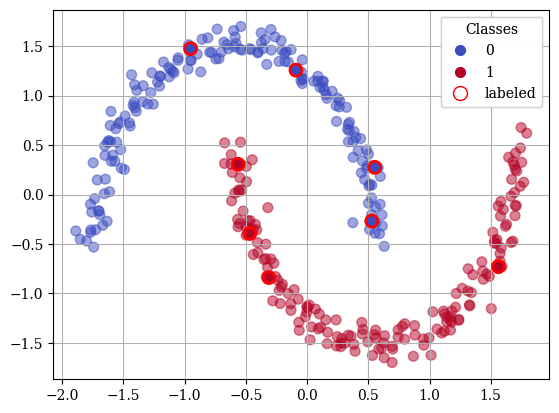

In [34]:
X, y = datasets.make_moons(350, noise=.05, random_state=42)
X = (X - X.mean(0)) / X.std(0)
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).long()

random.seed(1)
indices_class0 = [i for i in range(len(y)) if y[i] == 0]
indices_class1 = [i for i in range(len(y)) if y[i] == 1]
labeled_indices = random.sample(indices_class0, k=4) + random.sample(indices_class1, k=4)
unlabeled_indices = [i for i in range(X.shape[0]) if i not in labeled_indices]

X_labeled, y_labeled = X[labeled_indices], y[labeled_indices]
X_unlabeled, y_unlabeled = X[unlabeled_indices], y[unlabeled_indices]

labeled_ds = torch.utils.data.TensorDataset(X_labeled, y_labeled)
unlabeled_ds = torch.utils.data.TensorDataset(X_unlabeled, y_unlabeled)

plot_dset(X_l=X_labeled, y_l=y_labeled, X_u=X_unlabeled, y_u=y_unlabeled)
plt.show()

## Fully Supervised Model

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 17.2 K
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
17.2 K    Trainable params
0         Non-trainable params
17.2 K    Total params
0.069     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.


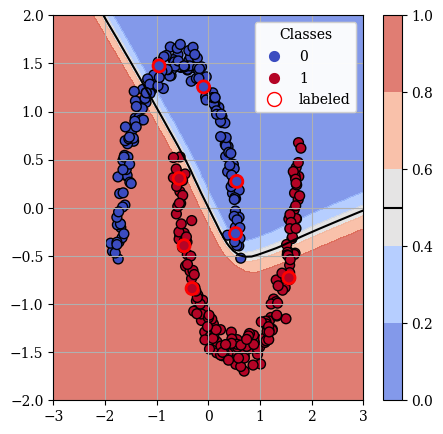

In [35]:
torch.manual_seed(0)

num_epochs = 100 # number of epochs for training
batch_size = 32 # batch_size of labeled samples per iteration

supervised_loader = DataLoader(labeled_ds, batch_size=batch_size)

opt_kwargs = dict(lr=0.01, weight_decay=0.0001, momentum=.9,)
model = Net(dropout_rate=0, num_classes=2)
optimizer = torch.optim.SGD(model.parameters(), **opt_kwargs)
model = DeterministicModel(model, optimizer=optimizer)

trainer = L.Trainer(enable_checkpointing=False, max_steps=num_epochs)
trainer.fit(model, train_dataloaders=supervised_loader)

model.eval()
plt.figure(figsize=(5, 5))
plot_contour(model, X_labeled, y_labeled, X_unlabeled, y_unlabeled, x_domain=(-3, 3), y_domain=(-2, 2))
plt.show()

## SimCLR

In [36]:
class InfoNCELoss(nn.Module):
    def __init__(self, temperature: float = 1.0) -> None:
        super().__init__()
        assert temperature > 0.0, "The temperature must be a positive float!"
        self.temperature = temperature

    def forward(self, batch):
        # Calculate cosine similarity
        cos_sim = F.cosine_similarity(batch[:, None, :], batch[None, :, :], dim=-1)
        # Mask out cosine similarity to itself
        self_mask = torch.eye(cos_sim.shape[0], dtype=torch.bool, device=cos_sim.device)
        cos_sim.masked_fill_(self_mask, -9e15)
        # Find positive example -> batch_size//2 away from the original example
        pos_mask = self_mask.roll(shifts=cos_sim.shape[0] // 2, dims=0)
        # InfoNCE loss
        cos_sim = cos_sim / self.temperature
        infoNCE = -cos_sim[pos_mask] + torch.logsumexp(cos_sim, dim=-1)
        infoNCE = infoNCE.mean()

        return infoNCE

In [37]:
class SimCLR(L.LightningModule):
    def __init__(self, 
                 encoder, 
                 projector, 
                 temperature = 1.0,
                 random_seed=42, 
                 n_epochs=200, 
                 optimizer_args = {'lr':1e-1, 'weight_decay':5e-4, 'nesterov':True, 'momentum':0.9}):
        super().__init__()
        self.encoder = encoder
        self.projector = projector
        self.loss_func = InfoNCELoss(temperature=temperature)
        self.random_seed = random_seed
        self.n_epochs = n_epochs
        self.optimizer_args = optimizer_args

    def training_step(self, batch, idx):
        samples, _ = batch
        samples = torch.cat(samples, dim=0)

        features = self.encoder(samples)
        projections = self.projector(features)

        loss = self.loss_func(projections)

        self.log_dict({'train_loss': loss})

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(
                params=self.parameters(), 
                **self.optimizer_args
                )
        lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=self.n_epochs)
        return [optimizer], [lr_scheduler]

In [38]:
def stochasitc_augmentation(X: torch.tensor, noise: float = 1):
    return X + torch.randn_like(X)*noise

class SSLDataset(torch.utils.data.TensorDataset):
    def __init__(self, data, targets, noise):
        self.tensors = [data, targets]
        self.noise = noise

    def __getitem__(self, idx):
        X, y = [t[idx] for t in self.tensors]
        return [stochasitc_augmentation(X, self.noise), stochasitc_augmentation(X, self.noise)], y
    
    def __len__(self):
        return self.tensors[0].shape[0]

In [39]:
aug_noise = 0.005
batch_size = 64
num_epochs = 1000
proj_dim = 16

# Build SimCLR Model
encoder = Net(num_classes=2, feature_dim=32)
feature_dim = encoder.last.in_features
num_classes = encoder.last.out_features
encoder.last = nn.Identity()
projector = nn.Sequential(
    nn.Linear(feature_dim, feature_dim),
    nn.ReLU(),
    nn.Linear(feature_dim, proj_dim)
)

simclr_model = SimCLR(
    encoder=encoder, 
    projector=projector,
    n_epochs=num_epochs)

# Build SimCLR Training Dataset
ssl_ds = SSLDataset(X, y, noise=aug_noise)
ssl_train_loader = torch.utils.data.DataLoader(
    ssl_ds, batch_size=batch_size, shuffle=True,
    num_workers=1, drop_last=True
)

# Pretrain the model
trainer = L.Trainer(enable_checkpointing=False, max_epochs=num_epochs)
trainer.fit(simclr_model, train_dataloaders=ssl_train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type        | Params
------------------------------------------
0 | encoder   | SimpleNet   | 1.2 K 
1 | projector | Sequential  | 1.6 K 
2 | loss_func | InfoNCELoss | 0     
------------------------------------------
2.7 K     Trainable params
0         Non-trainable params
2.7 K     Total params
0.011     Total estimated model params size (MB)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type             | Params
---------------------------------------------------
0 | model         | SimpleNet        | 1.2 K 
1 | loss_fn       | CrossEntropyLoss | 0     
2 | train_metrics | ModuleDict       | 0     
3 | val_metrics   | ModuleDict       | 0     
---------------------------------------------------
66        Trainable params
1.2 K     Non-trainable params
1.2 K     Total params
0.005     Total estimated model params size (MB)


first.weight
first.bias
hidden.weight
hidden.bias


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.


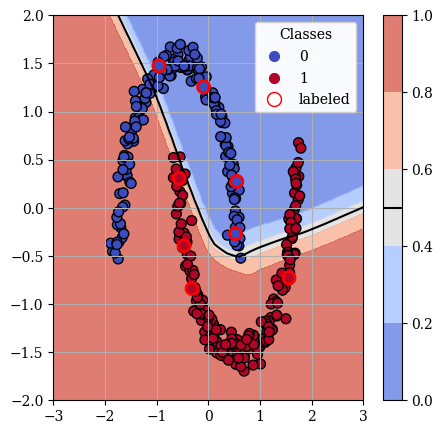

In [40]:
import copy

torch.manual_seed(0)

num_epochs = 100 # number of epochs for training
batch_size = 64 # batch_size of labeled samples per iteration

supervised_loader = DataLoader(labeled_ds, batch_size=batch_size)

# Extract the pretrained weights
model = copy.deepcopy(simclr_model.encoder)
model.last = nn.Linear(feature_dim, num_classes)

# freeze all layers but the last
for name, param in model.named_parameters():
    if name not in ['last.weight', 'last.bias']:
        print(name)
        param.requires_grad = False

opt_kwargs = dict(lr=0.1, weight_decay=0.0001, momentum=.9,)
optimizer = torch.optim.SGD(model.parameters(), **opt_kwargs)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
model = DeterministicModel(model, optimizer=optimizer, lr_scheduler=scheduler)

trainer = L.Trainer(enable_checkpointing=False, max_steps=num_epochs)
trainer.fit(model, train_dataloaders=supervised_loader)

model.eval()
plt.figure(figsize=(5, 5))
plot_contour(model, X_labeled, y_labeled, X_unlabeled, y_unlabeled, x_domain=(-3, 3), y_domain=(-2, 2))
plt.show()